# Exploratory Data Analysis of Mammography Imaging Data and Clinical Metadata

## Introduction

This notebook presents an exploratory data analysis (EDA) workflow performed on clinical imaging data and metadata associated with mammograms used for breast mass classification.

This analysis was developed as part of a broader deep learning project focused on convolutional neural networks (CNNs) for breast cancer detection.  
The objective of this notebook is to establish a robust and interpretable exploratory data analysis pipeline prior to model training.

The workflow includes:

- data and metadata loading and initial inspection;
- data and metadata integration;
- duplicated and missing values assessment;
- class distribution analysis;
- breast density vs pathology analysis;
- patient-level aggregation analysis;
- mass shape vs pathology analysis;
- SQL-based querying for structured analytical validation;
- training/test schema consistency, leakage detection, and class distribution checks;
- final training dataset export.

The notebook combines Pandas, SQL, and exploratory analytics techniques commonly used in real-world healthcare and machine learning pipelines.

### Technologies Used

- Google Colab
- Python
- Pandas
- Matplotlib
- Seaborn
- SQLite

### Analytical Context

Medical imaging datasets often contain heterogeneous metadata originating from multiple acquisition systems and annotation workflows. A rigorous exploratory phase is therefore essential to ensure data reliability, reproducibility, and interpretability before training predictive models.

This notebook emphasizes reproducible data handling practices and analytical transparency, both of which are critical in healthcare-oriented machine learning applications.

## Data Loading

The dataset consists of tabular CSV files including case descriptions and metadata associated with medical imaging studies. The project is designed to load data using relative paths to ensure clarity and reproducibility across different environments (local, Colab, or Jupyter).

Note: The actual CSV files are not included in this repository. Some CSV filenames have been slightly modified to distinguish training and test sets. They can be obtained from the original source [The Cancer Imaging Archive - CBIS-DDSM](https://www.cancerimagingarchive.net/collection/cbis-ddsm/).

In [ ]:
# Libraries for data manipulation, SQL querying, and visualization
from pathlib import Path
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Dataset paths
BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data"
RAW_DATA_PATH = DATA_PATH / "raw"
PROCESSED_DATA_PATH = DATA_PATH / "processed"


# Load train datasets
df_train = pd.read_csv(
    RAW_DATA_PATH /
    "mass_case_description_train_set.csv"
    )

meta_train = pd.read_csv(
    RAW_DATA_PATH /
    "metadata_train.csv"
    )


# Load test datasets
df_test = pd.read_csv(
    RAW_DATA_PATH /
    "mass_case_description_test_set.csv"
    )

meta_test = pd.read_csv(
    RAW_DATA_PATH /
    "metadata_test.csv"
    )

## Initial Data Inspection

### Training Set

We perform an initial inspection of the training dataset and metadata to understand their structures, sizes, and available features before proceeding with data integration and analysis.

Dataset overview:
- 1,318 mammography records with 14 clinical features
- 1,231 metadata entries with 18 DICOM-related attributes

In [ ]:
# Train dataset overview
print("=== Train dataset ===\n")
df_train.info()
print("Shape:", df_train.shape)

# Train metadata overview
print("\n\n\n=== Train metadata ===\n")
meta_train.info()
print("Shape:", meta_train.shape)

# Metadata missing values summary (percentage per column)
missing_rate_train = (
    meta_train
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
    .reset_index()
    .rename(columns={"index": "column"})
)

display(
    missing_rate_train.style.format({
        "missing_percentage": "{:.2f}%"
    })
)

=== Train dataset ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
dtypes: int64(4), obje

,column,missing_percentage
0,Study Description,100.00%
1,3rd Party Analysis,100.00%
2,Manufacturer,100.00%
3,Series UID,0.00%
4,Collection,0.00%
5,Data Description URI,0.00%
6,Study UID,0.00%
7,Subject ID,0.00%
8,Study Date,0.00%
9,Series Description,0.00%


Several metadata fields are entirely missing (100%), suggesting that these attributes are non-informative for downstream analytical and modeling tasks.

### Test Set

We perform an initial inspection of the test dataset and metadata to understand their structures, sizes, and available features before proceeding with data integration and analysis.

In [ ]:
# Test dataset overview
print("=== Test dataset ===\n")
df_test.info()
print("Shape:", df_test.shape)

# Test metadata overview
print("\n\n\n=== Test metadata ===\n")
meta_test.info()
print("Shape:", meta_test.shape)

# Metadata missing values summary (percentage per column)
missing_rate_test = (
    meta_test
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
    .reset_index()
    .rename(columns={"index": "column"})
)

display(
    missing_rate_test.style.format({
        "missing_percentage": "{:.2f}%"
    })
)

=== Test dataset ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               378 non-null    object
 1   breast_density           378 non-null    int64 
 2   left or right breast     378 non-null    object
 3   image view               378 non-null    object
 4   abnormality id           378 non-null    int64 
 5   abnormality type         378 non-null    object
 6   mass shape               378 non-null    object
 7   mass margins             361 non-null    object
 8   assessment               378 non-null    int64 
 9   pathology                378 non-null    object
 10  subtlety                 378 non-null    int64 
 11  image file path          378 non-null    object
 12  cropped image file path  378 non-null    object
 13  ROI mask file path       378 non-null    object
dtypes: int64(4), object(

,column,missing_percentage
0,Study Description,100.00%
1,3rd Party Analysis,100.00%
2,Manufacturer,100.00%
3,Series UID,0.00%
4,Collection,0.00%
5,Data Description URI,0.00%
6,Study UID,0.00%
7,Subject ID,0.00%
8,Study Date,0.00%
9,Series Description,0.00%


The same pattern of completely missing metadata fields is consistently observed in both training and test sets, confirming that these attributes are not informative across the entire dataset and will be excluded from further analysis.

## Data Integration and Merging

To enhance the analytical depth of the dataset, we join case description data with the associated metadata.

This integration enables the combination of clinical annotations with imaging acquisition information, supporting a more comprehensive exploratory data analysis and improving the contextual understanding of each medical study prior to machine learning modeling.

### Merging Preparation

We inspect column names to identify potential join keys and verify consistency between datasets before merging.

In [ ]:
print("Train dataset columns\n")

display(pd.DataFrame(
    df_train.columns,
    columns=["Columns"]
    ))

print("\n\nTrain dataset preview\n")

display(df_train[
    [
    "patient_id",
    "breast_density",
    "left or right breast",
    "image view",
    "mass shape",
    "mass margins",
    "assessment",
    "pathology",
    "subtlety"
    ]
].head(3))


print("\n\n\nTrain metadata columns\n")

display(pd.DataFrame(
    meta_train.columns,
    columns=["Columns"]
    ))

print("\n\nTrain metadata preview\n")

display(meta_train[
    [
    "Subject ID",
    "Series Description",
    "Modality",
    "Number of Images",
    "File Size"
    ]
].head(3))

Train dataset columns



,Columns
0,patient_id
1,breast_density
2,left or right breast
3,image view
4,abnormality id
5,abnormality type
6,mass shape
7,mass margins
8,assessment
9,pathology




Train dataset preview



,patient_id,breast_density,left or right breast,image view,mass shape,mass margins,assessment,pathology,subtlety
0,P_00001,3,LEFT,CC,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4
1,P_00001,3,LEFT,MLO,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4
2,P_00004,3,LEFT,CC,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3





Train metadata columns



,Columns
0,Series UID
1,Collection
2,3rd Party Analysis
3,Data Description URI
4,Subject ID
5,Study UID
6,Study Description
7,Study Date
8,Series Description
9,Manufacturer




Train metadata preview



,Subject ID,Series Description,Modality,Number of Images,File Size
0,Mass-Training_P_00001_LEFT_MLO,full mammogram images,MG,1,25
1,Mass-Training_P_00001_LEFT_CC,full mammogram images,MG,1,29
2,Mass-Training_P_00004_LEFT_MLO,full mammogram images,MG,1,33


We define and validate the variables used to construct join keys for merging clinical data and imaging metadata.

This includes checks for missing values, uniqueness, and structural consistency to ensure a reliable join strategy and avoid unintended row duplication during the merging process.

In [ ]:
# Check nullity, uniqueness and structural consistency of patient identifiers
print(
    "patient_id null rate: ",
    round(df_train["patient_id"].isna().mean() * 100, 2), "%", sep=""
    )

print(
    "\nUniqueness of patient_id elements:",
    df_train["patient_id"].is_unique
    )

print(
    "\nCardinality of patient_id elements:",
    df_train["patient_id"].nunique()
    )

print(
    "\n\nIdentifier length consistency of patient_id\n",
    )

display(df_train["patient_id"]
        .astype(str)
        .str
        .len()
        .describe()
        .to_frame(name="length_consistency"))


# Check nullity, uniqueness and structural consistency of Subject ID in metadata
print(
    "\n\n\nSubject ID null rate: ",
    round(meta_train["Subject ID"].isna().mean() * 100, 2), "%", sep=""
    )

print(
    "\nUniqueness of Subject ID elements:",
    meta_train["Subject ID"].is_unique
    )

print(
    "\nCardinality of Subject ID elements:",
    meta_train["Subject ID"].nunique()
    )

print(
    "\n\nIdentifier length consistency of Subject ID\n",
    )

display(meta_train["Subject ID"]
        .astype(str)
        .str
        .len()
        .describe()
        .to_frame(name="length_consistency"))

patient_id null rate: 0.0%

Uniqueness of patient_id elements: False

Cardinality of patient_id elements: 691


Identifier length consistency of patient_id



,length_consistency
count,1318.0
mean,7.0
std,0.0
min,7.0
25%,7.0
50%,7.0
75%,7.0
max,7.0





Subject ID null rate: 0.0%

Uniqueness of Subject ID elements: True

Cardinality of Subject ID elements: 1231


Identifier length consistency of Subject ID



,length_consistency
count,1231.000000
mean,30.054427
std,0.711893
min,29.000000
25%,30.000000
50%,30.000000
75%,31.000000
max,31.000000


Given the hierarchical structure of the dataset, a simple patient-level key is not sufficient to uniquely identify imaging records across different views and acquisitions.

To ensure a more robust alignment between clinical records and imaging metadata, we construct a composite join key that incorporates patient identifier, breast laterality, and imaging view after appropriate cleaning steps.

This approach preserves the hierarchical structure of the dataset while enabling a consistent and reproducible merging strategy across related datasets.

### Composite Key Construction

To support the construction of a reliable composite join key, we standardize the categorical fields related to breast laterality and imaging view associated with each patient record.

In particular, the corresponding labels are cleaned and normalized to ensure formatting consistency across datasets prior to merging.

In [ ]:
# Standardize and check breast laterality distribution
df_train["left or right breast"] = df_train["left or right breast"].str.strip().str.upper()

print("Left/Right breast distribution\n")
display(
    df_train["left or right breast"]
    .value_counts()
    .to_frame(name="count")
    .reset_index("left or right breast")
    .style.hide(axis="index")
    )


# Standardize and check image view distribution
df_train["image view"] = df_train["image view"].str.strip().str.upper()
print("\n\nImage view distribution\n")
display(
    df_train["image view"]
    .value_counts()
    .to_frame(name="count")
    .reset_index("image view")
    .style.hide(axis="index")
    )

Left/Right breast distribution



left or right breast,count
RIGHT,687
LEFT,631




Image view distribution



image view,count
MLO,711
CC,607


We assess the presence of missing join keys and perform consistency and uniqueness checks on both dataframes before merging.

In [ ]:
# Create join keys for training datasets
df_train["join_key"] = (
    df_train["patient_id"] + "_" +
    df_train["left or right breast"] + "_" +
    df_train["image view"]
)

meta_train["join_key"] = (
    meta_train["Subject ID"]
    .str.replace("Mass-Training_", "")
)


# Validate df_train join_key
assert df_train["join_key"].isnull().sum() == 0, \
    "df_train has missing join_key values"

print(
    "\nJoin key coverage (df_train -> meta_train): ",
    round(df_train["join_key"].isin(meta_train["join_key"]).mean() * 100, 2), "%", sep=""
    )

print(
    "\nUniqueness of df_train join_key:",
    df_train["join_key"].is_unique,
    "\n\n"
    )


# Validate meta_train join_key
assert meta_train["join_key"].isnull().sum() == 0, \
    "meta_train has missing join_key values"

print(
    "Join key coverage (meta_train -> df_train): ",
    round(meta_train["join_key"].isin(df_train["join_key"]).mean() * 100, 2), "%", sep=""
    )

print(
    "\nUniqueness of meta_train join_key:",
    meta_train["join_key"].is_unique
    )


Join key coverage (df_train -> meta_train): 100.0%

Uniqueness of df_train join_key: False 


Join key coverage (meta_train -> df_train): 100.0%

Uniqueness of meta_train join_key: True


These results suggest a consistent alignment between clinical and metadata records, while highlighting the presence of multiple imaging instances per patient.

### Merging Execution and Validation

Before merging, entirely null columns are removed from `meta_train`, as they do not provide any information for downstream analyses.

The two dataframes are then merged using the `join_key`. After the merge, we compare the shapes of the original and merged dataframes and verify that all expected columns are present in the resulting dataframe to validate the correctness of the operation.

In [ ]:
# Drop fully null columns from meta_train
null_cols = meta_train.columns[meta_train.isna().all()]
print(
    "Dropping fully null columns from meta_train:",
    list(null_cols)
    )
meta_train = meta_train.drop(columns=null_cols)


# Merge datasets
train_merged = df_train.merge(
    meta_train,
    on="join_key",
    how="left"
    )

print("\ndf_train shape:", df_train.shape)

print("\ntrain_merged shape:", train_merged.shape)


# Validate merge correctness
assert train_merged.shape[0] == df_train.shape[0], \
    "Row count mismatch between df_train and train_merged"

assert set(df_train.columns).issubset(train_merged.columns), \
    "Some df_train columns are missing after merge"

assert set(meta_train.columns).issubset(train_merged.columns), \
    "Some meta_train columns are missing after merge"

print("\nMerging validation passed successfully.")

Dropping fully null columns from meta_train: ['3rd Party Analysis', 'Study Description', 'Manufacturer']

df_train shape: (1318, 15)

train_merged shape: (1318, 30)

Merging validation passed successfully.


## Duplicated and Missing Values Assessment

After merging the clinical and metadata tables, we assess duplicated records and missing values to identify potential inconsistencies and evaluate overall data quality.

In [ ]:
# Check duplicate join keys
print(
    "Duplicate join keys:",
    train_merged["join_key"]
    .duplicated()
    .sum(),
    "\n"
    )


# Missing values summary
missing_summary = (
    pd.DataFrame({
        "missing_count": train_merged.isnull().sum(),
        "missing_percentage": train_merged.isnull().mean().mul(100)
        })
    .sort_values("missing_count", ascending=False)
    .head(10)
    )

display(
    missing_summary
    .style.format({
        "missing_percentage": "{:.2f}%"
        })
    )

Duplicate join keys: 87 



,missing_count,missing_percentage
mass margins,43,3.26%
mass shape,4,0.30%
left or right breast,0,0.00%
image view,0,0.00%
patient_id,0,0.00%
breast_density,0,0.00%
abnormality type,0,0.00%
abnormality id,0,0.00%
assessment,0,0.00%
pathology,0,0.00%


The final dataframe shows a relatively low proportion of missing values, as reflected by the corresponding percentages, which is consistent with expectations for a medical imaging dataset of this type.

The number of duplicate join keys is also limited and aligns with the hierarchical structure of the dataset.

## Class Distribution Analysis

We analyze the distribution of pathological classes to evaluate class balance and better understand the dataset composition prior to model development.

In [ ]:
# Class distribution
class_dist = pd.DataFrame({
    "count": train_merged["pathology"].value_counts(),
    "percentage": (
        train_merged["pathology"]
        .value_counts(normalize=True)
        .mul(100)
    )
}).reset_index(names="pathology")

display(
    class_dist
    .style.format({
        "percentage": "{:.2f}%"
        })
    .hide(axis="index")
    )

pathology,count,percentage
MALIGNANT,637,48.33%
BENIGN,577,43.78%
BENIGN_WITHOUT_CALLBACK,104,7.89%


The distribution between benign and malignant cases is relatively balanced across the dataset.

For the exploratory analysis, the original pathology labels are preserved to maintain consistency with the source dataset.  
However, during the CNN training phase, the `BENIGN_WITHOUT_CALLBACK` category is merged with `BENIGN` to formulate a binary classification problem focused on benign-versus-malignant lesion detection.

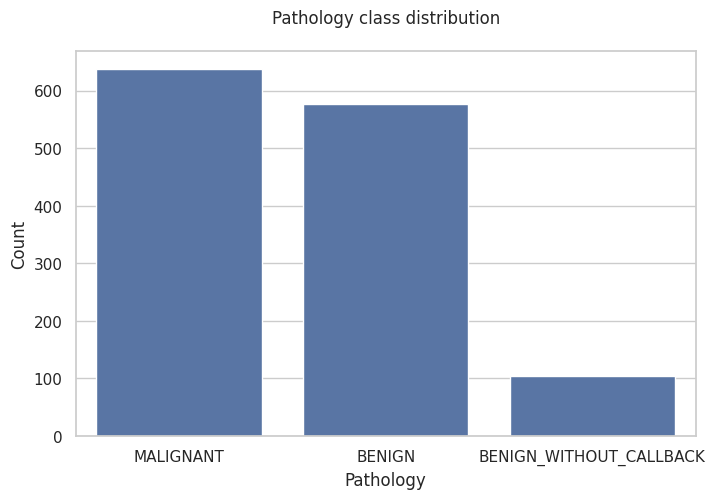

In [ ]:
# Class distribution plot
sns.countplot(
    data=train_merged,
    x="pathology"
    )

plt.title("Pathology class distribution", pad=20)
plt.xlabel("Pathology")
plt.ylabel("Count")

plt.show()

## Breast Density vs Pathology Analysis

We analyze the relationship between breast density and pathology to explore potential associations between anatomical characteristics and diagnostic outcomes.

In [ ]:
# Crosstab: breast density vs pathology
density_pathology_ct = pd.crosstab(
    train_merged["breast_density"],
    train_merged["pathology"]
)

density_pathology_ct.columns = pd.MultiIndex.from_product(
    [["pathology"], density_pathology_ct.columns]
)

density_pathology_ct = density_pathology_ct.reset_index()

display(
    density_pathology_ct
    .style.hide(axis="index")
    )

The distribution of benign and malignant cases is broadly similar across breast density categories.

No clear monotonic trend is observed, suggesting that breast density alone may not represent a strong discriminator of pathology in this dataset.

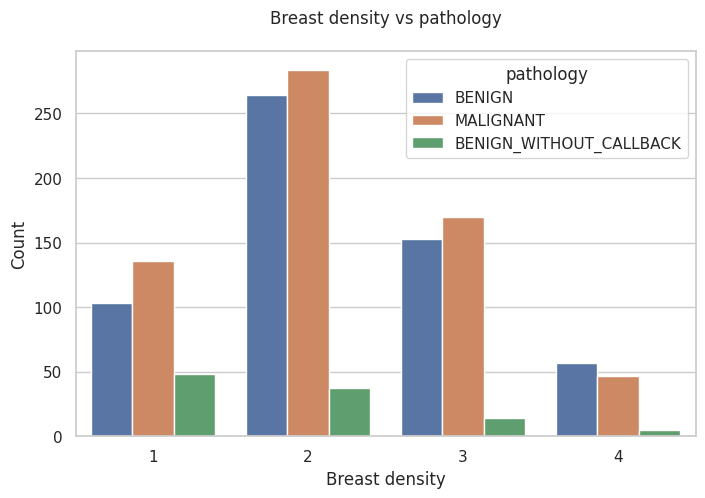

In [ ]:
# Crosstab plot: breast density vs pathology
sns.countplot(
    data=train_merged,
    x="breast_density",
    hue="pathology"
    )

plt.title("Breast density vs pathology", pad=20)
plt.xlabel("Breast density")
plt.ylabel("Count")

plt.show()

## Patient-Level Analysis

We analyze the distribution of cases per patient in the training dataset to gain insight into the presence of multiple imaging studies per individual. This analysis helps assess patient-level redundancy and better understand the overall dataset structure.

In [ ]:
# Unique patients
print(
    "Number of unique patient_id values:",
    train_merged["patient_id"].nunique()
    )


# Cases per patient summary
print("\n\nCases per patient distribution summary\n")
display(
    train_merged
    .groupby("patient_id")
    .size()
    .describe()
    .to_frame(name="cases_per_patient")
)

Number of unique patient_id values: 691


Cases per patient distribution summary



,cases_per_patient
count,691.000000
mean,1.907381
std,1.035649
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,14.000000


The hierarchical structure shows multiple imaging records corresponding to the same patient. This highlights patient-level redundancy, which must be considered carefully when designing data splits to avoid potential leakage in model training.

## Mass Shape vs Pathology Analysis

We explore the relationship between mass shape and pathology to investigate potential associations between lesion morphology and diagnostic outcomes.

In [ ]:
# Crosstab: mass shape vs pathology
mass_shape_ct = pd.crosstab(
    train_merged["mass shape"],
    train_merged["pathology"]
    )

mass_shape_ct.columns = pd.MultiIndex.from_product(
    [["pathology"],
     mass_shape_ct.columns]
    )

mass_shape_ct = mass_shape_ct.reset_index()

display(
    mass_shape_ct
    .style.hide(axis="index")
    )

The distribution suggests potential associations between specific mass shapes and pathology outcomes.

In particular, oval and lobulated shapes appear more frequently associated with benign findings, whereas irregular shapes appear associated with a substantially higher proportion of malignant cases.

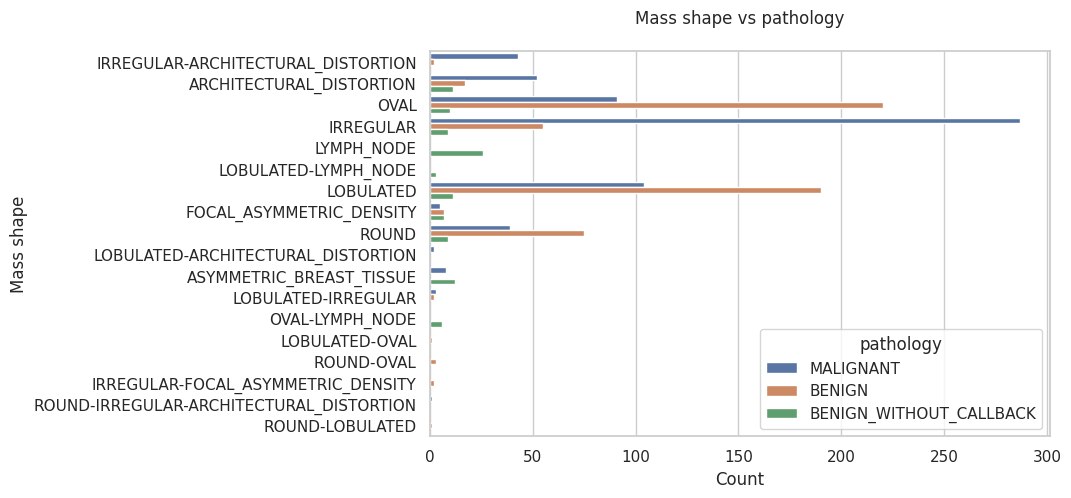

In [ ]:
# Crosstab plot: mass shape vs pathology
sns.countplot(
    data=train_merged,
    y="mass shape",
    hue="pathology"
    )

plt.legend(
    title="pathology",
    loc="lower right",
    frameon=True
    )
plt.title("Mass shape vs pathology", pad=20)
plt.xlabel("Count")
plt.ylabel("Mass shape")

plt.show()

## SQL-Based Analysis

We further analyze the same dataset using SQL queries to complement the Pandas-based data exploration.

In [ ]:
# Create in-memory SQLite database and load dataset
conn = sqlite3.connect(":memory:")

train_merged.to_sql(
    "mammography_train",
    conn,
    index=False,
    if_exists="replace"
)

1318

The merged train dataset was successfully loaded into an in-memory SQLite database, preserving data integrity with 1,318 records.

### Class Distribution

We use SQL to analyze the distribution of pathology classes and validate dataset balance from a relational perspective.

In [ ]:
# SQL: Pathology class distribution
query = """
SELECT
    pathology,
    COUNT(*) AS total_cases
FROM mammography_train
GROUP BY pathology
ORDER BY total_cases DESC
"""

display(
    pd.read_sql_query(query, conn)
    .style.hide(axis="index")
    )

pathology,total_cases
MALIGNANT,637
BENIGN,577
BENIGN_WITHOUT_CALLBACK,104


The results confirm the class distribution previously observed in the Pandas-based analysis, showing a broadly balanced dataset across the main pathology categories.

### Breast Density vs Pathology Distribution

We use SQL to validate the relationship between breast density and diagnostic categories, in line with the Pandas-based exploratory analysis.

In [ ]:
# SQL: Breast density vs pathology distribution
query = """
SELECT
    breast_density,
    pathology,
    COUNT(*) AS total_cases
FROM mammography_train
GROUP BY breast_density, pathology
ORDER BY breast_density, pathology
"""

display(
    pd.read_sql_query(query, conn)
    .style.hide(axis="index")
    )

breast_density,pathology,total_cases
1,BENIGN,103
1,BENIGN_WITHOUT_CALLBACK,48
1,MALIGNANT,136
2,BENIGN,264
2,BENIGN_WITHOUT_CALLBACK,37
2,MALIGNANT,284
3,BENIGN,153
3,BENIGN_WITHOUT_CALLBACK,14
3,MALIGNANT,170
4,BENIGN,57


The results confirm the breast density–pathology relationship previously observed in the Pandas-based analysis, showing consistent distributional patterns across both approaches.

No major discrepancies are observed between the SQL-based aggregation and the Pandas-derived analysis, confirming data consistency across both analytical methods.

## Training/Test Validation: Schema Consistency, Leakage and Class Distribution

We perform a structured consistency check between the training and test datasets to ensure data integrity before preprocessing and model development. We then assess schema alignment, potential patient-level overlap (leakage), and class distribution consistency across the two datasets.

In [ ]:
# Schema consistency check between train and test datasets
df_schema_match = df_train.columns.equals(df_test.columns)
meta_schema_match = meta_train.columns.equals(meta_test.columns)

if df_schema_match and meta_schema_match:

    print("Train and test datasets have the same schema.")

else:

    print("Schema mismatch detected between train and test datasets.\n")

    if not df_schema_match:

        print(
            "\nColumns only in df_train:",
            sorted(set(df_train.columns) - set(df_test.columns))
            )

        print("\nColumns only in df_test:",
              sorted(set(df_test.columns) - set(df_train.columns))
              )

    if not meta_schema_match:

        print(
            "\n\nColumns only in meta_train:",
            sorted(set(meta_train.columns) - set(meta_test.columns))
            )

        print(
            "\nColumns only in meta_test:",
            sorted(set(meta_test.columns) - set(meta_train.columns))
            )

Schema mismatch detected between train and test datasets.


Columns only in df_train: ['join_key']

Columns only in df_test: []


Columns only in meta_train: ['join_key']

Columns only in meta_test: ['3rd Party Analysis', 'Manufacturer', 'Study Description']


The schema mismatch is intentional and results from preprocessing steps applied to the training dataset, including the creation of the join_key column for merging purposes and the removal of non-informative fully null columns from meta_train.

Excluding these intentional and auxiliary differences, the training and test schemas are fully consistent for downstream analysis.

In [ ]:
# Check patient overlap between train and test sets
overlap = set(df_train["patient_id"]).intersection(set(df_test["patient_id"]))

print("Patient overlap between train and test sets:", len(overlap), "\n\n")


# Compare percentage class distribution between train and test sets
train_test_class = (
    pd.DataFrame({
        "train": df_train["pathology"].value_counts(normalize=True),
        "test": df_test["pathology"].value_counts(normalize=True)
        })
    .mul(100)
    .reset_index(names="pathology")
    )

display(
    train_test_class
    .style.format({
        "train": "{:.2f}%",
        "test": "{:.2f}%"
        })
    .hide(axis="index")
    )

Patient overlap between train and test sets: 0 




pathology,train,test
BENIGN,43.78%,51.32%
BENIGN_WITHOUT_CALLBACK,7.89%,9.79%
MALIGNANT,48.33%,38.89%


No patient overlap is observed between the training and test sets, indicating the absence of patient-level data leakage.

Additionally, the comparison of pathology distributions shows no major imbalance between the two splits, suggesting consistent class representation across datasets.

Overall, these results support the suitability of both datasets for downstream machine learning tasks, including model training and evaluation.

## Export Training Dataset

We export the processed dataset to support downstream analytics and reporting workflows (e.g., BI tools such as Power BI or Excel).


In [ ]:
# Export merged dataset to CSV
output_path = PROCESSED_DATA_PATH / "mammography_train_merged.csv"

train_merged.to_csv(output_path, index=False)

print("Merged dataset exported successfully to:", output_path)

Merged dataset exported successfully to: /content/drive/MyDrive/mammography-cnn-classification/data/processed/mammography_train_merged.csv


## Conclusions

This notebook presented an end-to-end Pandas- and SQL-based exploratory data analysis pipeline applied to tabular medical data and metadata.

After appropriate merging preparation, execution, and validation of data and metadata, a detailed inspection was performed to assess structural consistency (missing and unique values) and class distribution, with a focus on potential imbalance for downstream analytics.

Additionally, selected imaging features (breast density and mass shape) were analyzed in relation to pathology to explore their distributions and potential diagnostic associations.

Finally, training-test schema consistency and class balance checks validated dataset transparency and reproducibility for downstream analytics, reporting, and machine learning training.